##### Imports

In [8]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

##### Reading Data

In [9]:
full_dataset = pd.read_csv('full_dataset.csv')

In [10]:
full_dataset.head(3)

,retail_id,order_value_mean,order_value_sum,order_value_std,order_value_max,carton_count_mean,carton_count_std,line_of_factor_mean,line_of_factor_std,total_duration,avg_interval,last_interval,growth_rate,class
0,R_002acad30d17,0.165596,0.662386,0.087745,0.285496,0.338636,0.147266,0.653846,0.189594,38.0,12.666667,20.0,-0.674462,1.0
1,R_011da1723877,0.043140,0.172560,0.004318,0.048219,0.080682,0.007763,0.137363,0.036446,28.0,9.333333,8.0,0.199462,1.0
2,R_02594d5e71d2,0.017103,0.068412,0.012570,0.032619,0.030682,0.018323,0.071429,0.042560,46.0,15.333333,23.0,5.509571,1.0


In [112]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   retail_id            200 non-null    object 
 1   order_value_mean     200 non-null    float64
 2   order_value_sum      200 non-null    float64
 3   order_value_std      200 non-null    float64
 4   order_value_max      200 non-null    float64
 5   carton_count_mean    200 non-null    float64
 6   carton_count_std     200 non-null    float64
 7   line_of_factor_mean  200 non-null    float64
 8   line_of_factor_std   200 non-null    float64
 9   total_duration       200 non-null    float64
 10  avg_interval         200 non-null    float64
 11  last_interval        200 non-null    float64
 12  growth_rate          200 non-null    float64
 13  class                120 non-null    float64
dtypes: float64(13), object(1)
memory usage: 22.0+ KB


In [13]:
# preparing train data
train_data = full_dataset.dropna(subset=['class']).copy()
X = train_data.drop(columns=['retail_id', 'class'])
y = train_data['class']

In [14]:
# scaling features (features that we added weren't scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# defining models with hyperparameters
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=7, criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=7, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=7, n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(8, 4), alpha=0.1, max_iter=500, random_state=42)
}

In [16]:
# cross val 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []

for name, model in models.items():
    cv_res = cross_validate(model, X_scaled, y, cv=skf, scoring=['roc_auc', 'f1'])
    results_list.append({
        "Model": name,
        "ROC-AUC": cv_res['test_roc_auc'].mean(),
        "F1-Score": cv_res['test_f1'].mean()
    })

In [17]:
results_list

[{'Model': 'Logistic Regression',
  'ROC-AUC': np.float64(0.6031746031746031),
  'F1-Score': np.float64(0.8455784865540963)},
 {'Model': 'Decision Tree',
  'ROC-AUC': np.float64(0.6031746031746033),
  'F1-Score': np.float64(0.9147456986197768)},
 {'Model': 'Random Forest',
  'ROC-AUC': np.float64(0.6603174603174603),
  'F1-Score': np.float64(0.9333333333333333)},
 {'Model': 'XGBoost',
  'ROC-AUC': np.float64(0.6142857142857143),
  'F1-Score': np.float64(0.9284848484848485)},
 {'Model': 'Neural Network (MLP)',
  'ROC-AUC': np.float64(0.5238095238095238),
  'F1-Score': np.float64(0.9223960535588442)}]

In [18]:
# showing results as a df
comparison_df = pd.DataFrame(results_list).sort_values(by="ROC-AUC", ascending=False)
comparison_df

,Model,ROC-AUC,F1-Score
2,Random Forest,0.660317,0.933333
3,XGBoost,0.614286,0.928485
1,Decision Tree,0.603175,0.914746
0,Logistic Regression,0.603175,0.845578
4,Neural Network (MLP),0.523810,0.922396


##### Predicting based on the best model - Random Forest

In [19]:
# defining final model
final_model = RandomForestClassifier(
    class_weight='balanced', 
    n_estimators=200, 
    max_depth=7, 
    random_state=42
)

In [20]:
# fitting on all labeled data (120 users)
final_model.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [21]:
# Preparing data for the 80 unlabeled users
predict_data = full_dataset[full_dataset['class'].isnull()].copy()
X_predict = predict_data.drop(columns=['retail_id', 'class'])
X_predict_scaled = scaler.transform(X_predict)

In [22]:
# predicting class and probability
predict_data['predicted_class'] = final_model.predict(X_predict_scaled)
predict_data['predicted_proba'] = final_model.predict_proba(X_predict_scaled)[:, 1]

In [27]:
# saving .csv file
predictions_csv = predict_data[['retail_id', 'predicted_class', 'predicted_proba']]
predictions_csv.to_csv('predictions_randomforest_hardcode.csv', index=False)


##### Feature importance

In [24]:
# extracting feature importance
importances = final_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [25]:
feature_importance_df

,Feature,Importance
10,last_interval,0.135655
8,total_duration,0.125062
9,avg_interval,0.107638
5,carton_count_std,0.106591
7,line_of_factor_std,0.100929
11,growth_rate,0.086123
2,order_value_std,0.062782
3,order_value_max,0.061682
0,order_value_mean,0.059505
4,carton_count_mean,0.057781


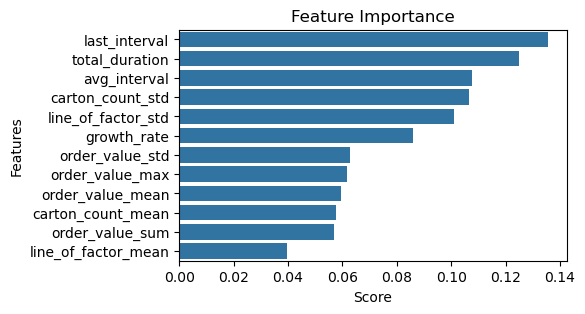

In [26]:
plt.figure(figsize=(5, 3))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Score')
plt.ylabel('Features')
plt.show()